<a href="https://colab.research.google.com/github/lctung/fontdiffuser-finetune-colab/blob/main/FontDiffuser_sample.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# 步驟一： 下載助教的 Github 專案 (Fontdiffuser)

---

In [ ]:
!git clone https://github.com/lctung/fontdiffuser-finetune.git
%cd fontdiffuser-finetune
import os
os.rename("characters.txt", "V.txt")

# 步驟二：下載並安裝 torch 函式庫

---
### **注意：下面這格程式執行中會需要按一次enter**

In [ ]:
# 安裝 Python 3.10
!sudo apt-get update -y
!sudo apt-get install python3.10 python3.10-distutils python3.10-dev -y

# 切換默認 python 版本
!sudo update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.12 1
!sudo update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.10 2
!sudo update-alternatives --config python3

# 重新安裝 pip
!curl -sS https://bootstrap.pypa.io/get-pip.py | python3.10

In [ ]:
!pip install torch==2.0.1 torchvision==0.15.2 torchaudio==2.0.2 --index-url https://download.pytorch.org/whl/cu117

In [ ]:
import torch
print("GPU 可用:", torch.cuda.is_available())
print("PyTorch 版本:", torch.__version__)

# 步驟三：安裝 requirements.txt 所需套件

---

In [ ]:
!pip install -r requirements.txt

# 步驟四：從自己的 Google Drive 載入之前訓練好的模型微調權重檔

---
### 注意：source_folder 的路徑中，是否有 global_step_5000 這個資料夾
### 注意：有做過 finetune 後，預設就會放在這個資料夾，請檢查是否存在

In [ ]:
# 切換工作目錄
%cd /content/fontdiffuser-finetune

# 安裝 gdown（如果尚未安裝）
!pip install -U gdown

# 建立 ckpt 資料夾（如果尚未存在）
!mkdir -p ckpt

# 下載 scr_210000.pth 檔案
!gdown --id 1UF4nIcL3PRJeQOQOPFFuGzj30v67rlNn -O ckpt/scr_210000.pth

# 掛載 Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 複製三個 checkpoint 檔案到 /content/fontdiffuser-finetune/ckpt
import shutil
import os

# 設定來源與目標路徑
source_folder = '/content/drive/MyDrive/Fontdiffuser_finetuning_ckpt/global_step_5000'
target_folder = '/content/fontdiffuser-finetune/ckpt'

# 建立目標資料夾（若不存在）
os.makedirs(target_folder, exist_ok=True)

# 要複製的檔案列表
files_to_copy = ['content_encoder.pth', 'style_encoder.pth', 'unet.pth']

# 複製檔案
for file_name in files_to_copy:
    shutil.copy(os.path.join(source_folder, file_name), os.path.join(target_folder, file_name))

print("✅ 所有檔案下載與複製完成")


# 步驟五：上傳風格參考圖

---
執行後會出現一個按鈕，點下後會跳出視窗，找到你的訓練集，從中挑選一張筆畫較繁雜的字，作為風格參考圖

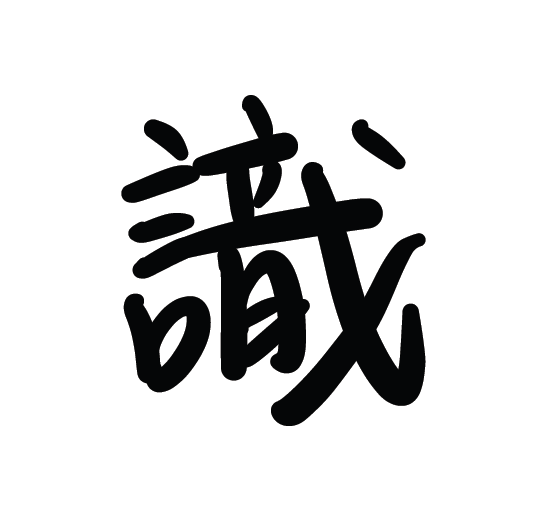

In [ ]:
from google.colab import files
import os
import shutil

# 1. 使用者上傳一張圖片
uploaded = files.upload()

# 2. 取得第一張圖片的檔名與副檔名
filename = next(iter(uploaded))  # 取第一個 key（檔名）
ext = os.path.splitext(filename)[1]  # 副檔名，例如 '.jpg'
target_dir = "/content/fontdiffuser-finetune/data_examples/sampling"

# 3. 重新命名並移動
new_filename = f"example_style.jpg"
target_path = os.path.join(target_dir, new_filename)
shutil.move(filename, target_path)

print(f"✅ 檔案已上傳並移動到：{target_path}")

# 步驟六：檢查 V.txt 內容
---
- 在開始生成前，請點擊畫面左側檔案，點開 fontdiffuser-finetune 找到 V.txt，確認內容是不是你想要生成的字
- 如需更改內容，有兩個方法
  1. 可以直接編輯這個檔案，把要生成的字輸入進去，並跳過此步驟
  2. 從原始檔案計算出尚未生成的字，請執行以下這個 cell

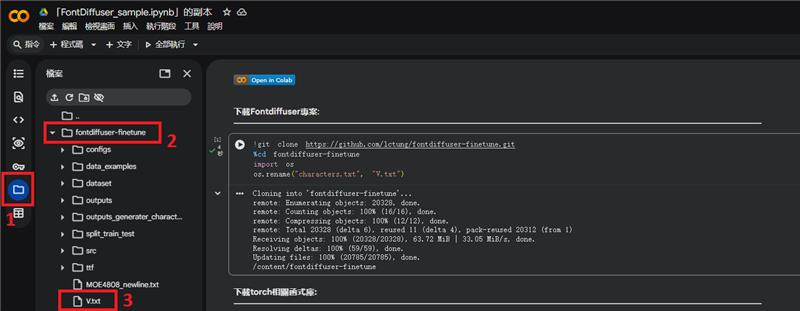

In [ ]:
# 不同範圍要自己加
manucripts_text = "/content/fontdiffuser-finetune/write_newline.txt"
font_package_text = "/content/fontdiffuser-finetune/MOE4808_newline.txt"

with open(manucripts_text, "r", encoding="utf-8") as file:
    manucripts_text = file.read()
with open(font_package_text, "r", encoding="utf-8") as file:
    font_package_text = file.read()

# 設定不同集合
set_manucripts_text = set(manucripts_text)
set_font_package_text = set(font_package_text)

unseen_char = set_font_package_text - set_manucripts_text

unseen_char_newline = "\n".join(unseen_char)

output_path = "/content/fontdiffuser-finetune/V.txt"
with open(output_path, "w", encoding="utf-8") as file:
    file.write(unseen_char_newline)

print(f"成功修改 {output_path} 內容")


# 步驟七：開始進行字體生成

---

- 生成的字體會存在 outputs_generater_character_list
- Colab 有流量限制，一天大概可以生成4000字左右
- 在流量終止前，請手動終止**步驟七**，並前往**步驟八**，執行後續修改圖檔與下載資料夾等動作

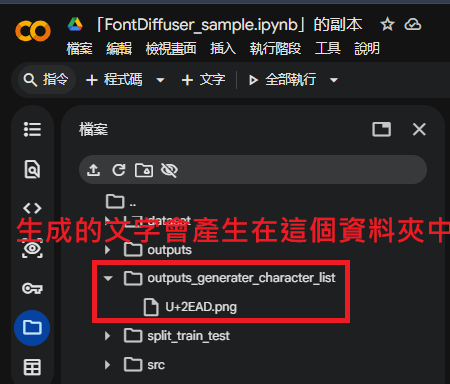

In [ ]:
%cd /content/fontdiffuser-finetune
!python sample.py \
  --ckpt_dir="ckpt/" \
  --style_image_path="data_examples/sampling/example_style.jpg" \
  --save_image \
  --character_input \
  --character_list_path="V.txt" \
  --save_image_dir="outputs_generater_character_list/" \
  --device="cuda:0" \
  --algorithm_type="dpmsolver++" \
  --guidance_type="classifier-free" \
  --guidance_scale=7.5 \
  --num_inference_steps=20 \
  --method="multistep"


# 步驟八：修改圖檔大小

---
將圖片調整為 300*300 的大小


In [ ]:
from PIL import Image
import os
from pathlib import Path

# 設定圖片資料夾路徑
image_folder = 'outputs_generater_character_list'  # 請將此處替換為您的資料夾路徑

# 取得所有 PNG 檔案
png_files = list(Path(image_folder).glob('*.png'))

for file_path in png_files:
    try:
        with Image.open(file_path) as img:
            # 調整圖片大小為 300x300
            img_resized = img.resize((300, 300), Image.LANCZOS)
            # 儲存並覆蓋原始檔案
            img_resized.save(file_path)
            print(f"已處理：{file_path.name}")
    except Exception as e:
        print(f"處理 {file_path.name} 時發生錯誤：{e}")


# 步驟九：壓縮生成圖片檔案並下載

---

下載此資料夾到自己的電腦，否則離線後，資料夾會消失

In [ ]:
!zip -r outputs_generater_character_list.zip outputs_generater_character_list
from google.colab import files
files.download('outputs_generater_character_list.zip')